# Greeks & Implied Volatility

This notebook covers the option Greeks, sensitivities of the option price to each input, and implied volatility, the market's estimate of future uncertainty.

---

## 1. The Greeks

The Greeks are partial derivatives of the Black-Scholes formula with respect to each input parameter.

Delta $(\Delta)$: sensitivity of option price to stock price. For a call, $\Delta = N(d_1)$.

Gamma $(\Gamma)$: rate of change of Delta. Peaks at the money where Delta changes fastest.

Vega $(\mathcal{V})$: sensitivity to volatility. Always positive for both calls and puts.

Theta $(\Theta)$: value lost per calendar day from time passing. Almost always negative.

Rho $(\rho)$: sensitivity to the risk-free interest rate.

In [7]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from greeks import greeks
from implied_vol import implied_volatility, plot_vol_smile

## 2. Greeks at a Single Point

In [21]:
S, K, T, r, sigma = 150, 155, 0.5, 0.05, 0.20

g = greeks(S, K, T, r, sigma)

print(f"Delta (call): {g['delta_call']:.4f} - call price increases ${g['delta_call']:.2f} per $1 rise in stock")
print(f"Delta (put): {g['delta_put']:.4f} - put price changes ${g['delta_put']:.2f} per $1 rise in stock")
print(f"Gamma: {g['gamma']:.4f} - Delta changes by {g['gamma']:.4f} per $1 rise in stock")
print(f"Vega: {g['vega']:.4f} - price changes ${g['vega']:.2f} per 1% rise in volatility")
print(f"Theta (call): {g['theta_call']:.4f} - call loses ${abs(g['theta_call']):.4f} per day")
print(f"Theta (put): {g['theta_put']:.4f} - put loses ${abs(g['theta_put']):.4f} per day")
print(f"Rho (call): {g['rho_call']:.4f} - price changes ${g['rho_call']:.2f} per 1% rise in rates")
print(f"Rho (put): {g['rho_put']:.4f} - price changes ${g['rho_put']:.2f} per 1% rise in rates")

Delta (call): 0.5062 - call price increases $0.51 per $1 rise in stock
Delta (put): -0.4938 - put price changes $-0.49 per $1 rise in stock
Gamma: 0.0188 - Delta changes by 0.0188 per $1 rise in stock
Vega: 0.4231 - price changes $0.42 per 1% rise in volatility
Theta (call): -0.0325 - call loses $0.0325 per day
Theta (put): -0.0118 - put loses $0.0118 per day
Rho (call): 0.3401 - price changes $0.34 per 1% rise in rates
Rho (put): -0.4158 - price changes $-0.42 per 1% rise in rates


## 3. Greeks Across Stock Prices

Delta follows an S-curve from 0 to 1 as the stock price rises through the strike. Gamma and Vega are bell-shaped, peaking at the money where the option is most sensitive to changes in the underlying.

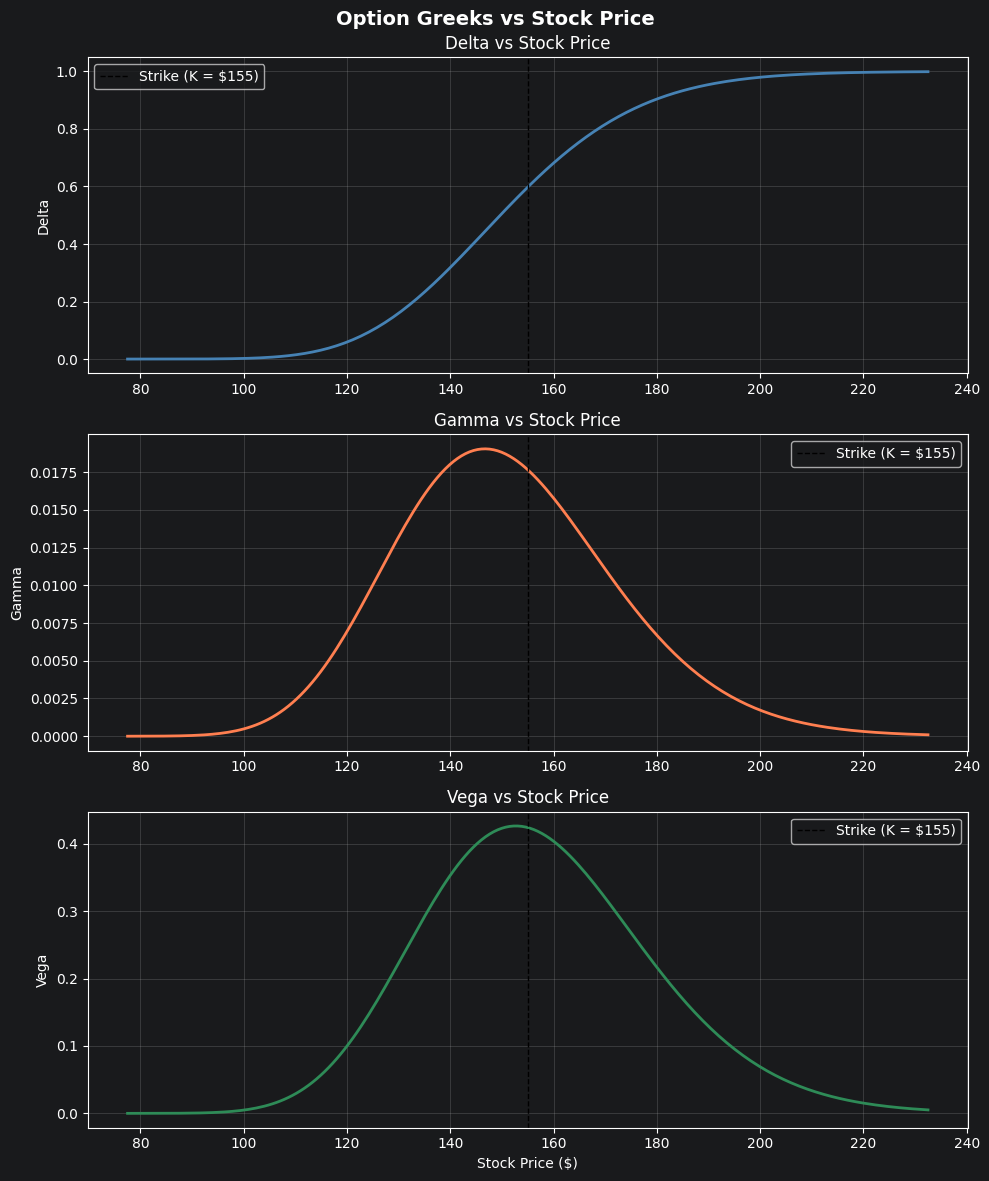

In [9]:
stock_prices = np.linspace(K * 0.5, K * 1.5, 200)

deltas, gammas, vegas = [], [], []
for s in stock_prices:
    g = greeks(s, K, T, r, sigma)
    deltas.append(g["delta_call"])
    gammas.append(g["gamma"])
    vegas.append(g["vega"])

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(stock_prices, deltas, color="steelblue", linewidth=2)
axes[0].axvline(x=K, color="black", linestyle="--", linewidth=1, label=f"Strike (K = ${K})")
axes[0].set_title("Delta vs Stock Price", fontsize=12)
axes[0].set_ylabel("Delta")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(stock_prices, gammas, color="coral", linewidth=2)
axes[1].axvline(x=K, color="black", linestyle="--", linewidth=1, label=f"Strike (K = ${K})")
axes[1].set_title("Gamma vs Stock Price", fontsize=12)
axes[1].set_ylabel("Gamma")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(stock_prices, vegas, color="seagreen", linewidth=2)
axes[2].axvline(x=K, color="black", linestyle="--", linewidth=1, label=f"Strike (K = ${K})")
axes[2].set_title("Vega vs Stock Price", fontsize=12)
axes[2].set_ylabel("Vega")
axes[2].set_xlabel("Stock Price ($)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Option Greeks vs Stock Price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/greeks.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Implied Volatility

Volatility $\sigma$ is the only unobservable input to Black-Scholes. Given a market price, we invert the formula numerically to recover the implied volatility, the $\sigma$ that makes Black-Scholes reproduce the observed price.

We use Brent's method, a root-finding algorithm, to solve:

$$\text{BS}(S, K, T, r, \sigma^*) - C_{market} = 0$$

In [22]:
# if market price equals our BS price, IV should return exactly sigma
bs_price = 7.92
iv = implied_volatility(bs_price, S, K, T, r)
print(f"Market price: ${bs_price}  ->  Implied vol: {iv*100:.2f}%")

print("\nHow implied vol varies with market price:")
for price in [5.00, 7.92, 10.00, 13.00, 16.00]:
    iv = implied_volatility(price, S, K, T, r)
    print(f"${price:.2f} -> {iv*100:.2f}%")

Market price: $7.92  ->  Implied vol: 20.01%

How implied vol varies with market price:
$5.00 -> 13.11%
$7.92 -> 20.01%
$10.00 -> 24.93%
$13.00 -> 32.03%
$16.00 -> 39.16%


## Summary

- The Greeks measure how sensitive the option price is to each input
- Delta is the primary hedge ratio, it tells you how many shares to hold to offset option exposure
- Gamma and Vega peak at the money, where the option is most sensitive to market moves
- Implied volatility is the market's forward-looking uncertainty estimate baked into option prices